In [1]:
import os
import gzip
import pickle
import numpy as np
import pandas as pd


# ====== score vector column names (matches get_metrics return order) ======
SCORE_COLS = ["aupr", "auc", "f1", "accuracy", "recall", "specificity", "precision"]

# ====== hyperparam columns per method ======
HYPERPARAM_COLS = {
    "bissgl": [
        "xi",
        "eta",
        "tilde_lambda0",
        "tilde_lambda1",
        "lambda0",
        "lambda1",
        "K",
    ],
    "sgimc": ["C_lasso", "C_group", "C_ridge", "rank"],
    "imc": ["C_lasso", "C_group", "C_ridge", "lamb", "rank"],
    "drimc": ["lamU", "lamV", "cc", "iterpara", "numLat"],
    "nrlmf": [
        "c",
        "K1",
        "K2",
        "r",
        "lambda_d",
        "lambda_t",
        "alpha",
        "beta",
        "theta",
        "max_iter",
    ],
}


# ====== load results — single stacked file or multiple task files ======
def load_results(output_dir, method_name):
    """
    Load results for a given method. Handles two cases:
      1. Single stacked file:  results_<method>.gz
      2. Multiple task files:  results_<method>_task*.gz

    Parameters
    ----------
    output_dir  : str  path to the directory containing result files
    method_name : str  one of 'bissgl', 'sgimc', 'imc'

    Returns
    -------
    pd.DataFrame  one row per (dataset, train_size, hyperparam combo, cv fold)
    """
    # prefer single stacked file if it exists
    single_file = os.path.join(output_dir, f"results_{method_name}.gz")
    if os.path.exists(single_file):
        with gzip.open(single_file, "rb") as fin:
            rows = pickle.load(fin)
    else:
        # fall back to multiple task files
        prefix = f"results_{method_name}_task"
        files = sorted(
            f
            for f in os.listdir(output_dir)
            if f.startswith(prefix) and f.endswith(".gz")
        )
        if not files:
            raise FileNotFoundError(
                f"No file 'results_{method_name}.gz' and no task files "
                f"matching '{prefix}*.gz' found in {output_dir}"
            )
        rows = []
        for fname in files:
            with gzip.open(os.path.join(output_dir, fname), "rb") as fin:
                rows.extend(pickle.load(fin))

    df = pd.DataFrame(rows)
    df["val_score"] = df["val_score"].apply(np.asarray)
    df["test_score"] = df["test_score"].apply(np.asarray)
    return df


# ====== expand score vector into named columns ======
def expand_scores(df, col, names=SCORE_COLS):
    """
    Expand a column of score vectors into individual named columns.
    Returns a new DataFrame with columns: <col>_aupr, <col>_auc, etc.
    """
    expanded = pd.DataFrame(
        np.stack(df[col].values), index=df.index, columns=[f"{col}_{n}" for n in names]
    )
    return expanded


# ====== main summarization pipeline ======
def summarize_results(
    df,
    hyperparam_cols,
    val_metric="aupr",
):
    """
    Summarize simulation results with CV-based hyperparameter selection.

    Pipeline
    --------
    1. Average val_score across CV folds per (feature_id, repeat_id, train_size, hyperparams)
    2. Select best hyperparam combo per (feature_id, repeat_id, train_size) by val_metric
    3. Retrieve test_score for the best combo (identical across CV folds — take first row)
    4. Average and std of test_score across repeat_ids per (feature_id, n_features, train_size)

    Parameters
    ----------
    df             : pd.DataFrame  raw results from load_results()
    hyperparam_cols: list[str]     hyperparam column names for this method
    val_metric     : str           which score metric to use for selection (default: 'aupr')

    Returns
    -------
    dict with keys:
        'val_avg'      : val scores averaged over CV folds, per (feature, repeat, train, hyperparams)
        'best_params'  : best hyperparam combo per (feature, repeat, train)
        'test_per_rep' : test scores for best combo per (feature, repeat, train)
        'final'        : mean and std of test scores across repeats per (feature, train)
    """

    id_cols = ["feature_id", "n_features", "repeat_id"]
    cond_cols = ["train_size"]
    # sel_cols = all columns that identify a unique (dataset, condition) pair
    sel_cols = id_cols + cond_cols
    group_cols = sel_cols + hyperparam_cols

    # ------------------------------------------------------------------
    # Step 1: average val_score across CV folds
    # ------------------------------------------------------------------
    val_avg = df.groupby(group_cols, as_index=False).agg(
        val_score=("val_score", lambda x: np.mean(np.stack(x), axis=0)),
        # val_d1=("val_d1", "mean"),
        # val_d2=("val_d2", "mean"),
    )

    # expand val_score vector into named columns for readability
    val_avg = pd.concat(
        [val_avg.drop(columns=["val_score"]), expand_scores(val_avg, "val_score")],
        axis=1,
    )
    val_metric_col = f"val_score_{val_metric}"

    # ------------------------------------------------------------------
    # Step 2: select best hyperparam combo per (feature_id, repeat_id, train_size)
    # ------------------------------------------------------------------
    sel_cols = id_cols + cond_cols
    best_idx = val_avg.groupby(sel_cols)[val_metric_col].idxmax()
    best_params = val_avg.loc[
        best_idx, sel_cols + hyperparam_cols + [val_metric_col]
    ].reset_index(drop=True)

    # ------------------------------------------------------------------
    # Step 3: retrieve test_score for the best combo
    # test_score is identical across CV folds for the same combo,
    # so merge and take the first row per group
    # ------------------------------------------------------------------
    df_best = df.merge(
        best_params[sel_cols + hyperparam_cols],
        on=sel_cols + hyperparam_cols,
        how="inner",
    )

    # deduplicate: one row per (feature_id, repeat_id, train_size)
    test_per_rep = df_best.groupby(sel_cols, as_index=False).first()[
        # sel_cols + hyperparam_cols + ["test_score", "test_d1", "test_d2"]
        sel_cols
        + hyperparam_cols
        + ["test_score"]
    ]

    # expand test_score vector into named columns
    test_per_rep = pd.concat(
        [
            test_per_rep.drop(columns=["test_score"]),
            expand_scores(test_per_rep, "test_score"),
        ],
        axis=1,
    )

    # ------------------------------------------------------------------
    # Step 4: average and std across repeat_ids per (feature_id, train_size)
    # ------------------------------------------------------------------
    test_score_cols = [f"test_score_{n}" for n in SCORE_COLS]

    final = test_per_rep.groupby(
        ["feature_id", "n_features", "train_size"], as_index=False
    ).agg(
        **{f"{c}_mean": (c, "mean") for c in test_score_cols},
        **{f"{c}_std": (c, lambda x: x.std(ddof=1)) for c in test_score_cols},
        # test_d1_mean=("test_d1", "mean"),
        # test_d2_mean=("test_d2", "mean"),
        n_repeats=("repeat_id", "count"),
    )

    return {
        "val_avg": val_avg,
        "best_params": best_params,
        "test_per_rep": test_per_rep,
        "final": final,
    }


# ====== convenience wrapper per method ======
def summarize_method(output_dir, method_name, val_metric="aupr", filters=None):
    """
    Load results and summarize for a given method in one call.

    Parameters
    ----------
    output_dir  : str   path to result files
    method_name : str   one of 'bissgl', 'sgimc', 'imc'
    val_metric  : str   score metric for hyperparam selection (default: 'aupr')
    filters     : dict  optional column filters applied before summarization,
                        e.g. {"xi": 1} to restrict to xi=1 rows only

    Example
    -------
    results = summarize_method(
        output_dir  = "/work/sfan/projects/BiSSGL/outputs/simulations/n_features",
        method_name = "bissgl",
        val_metric  = "aupr",
        filters     = {"xi": 1},
    )
    print(results["final"])
    """
    hyperparam_cols = HYPERPARAM_COLS[method_name]
    df = load_results(output_dir, method_name)

    if filters is not None:
        for col, val in filters.items():
            df = df[df[col] == val]
        df = df.reset_index(drop=True)

    return summarize_results(df, hyperparam_cols, val_metric=val_metric)

In [2]:
import os
from sgimc.utils import load
import glob

In [3]:
PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/simulations/n_features")
PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/simulations/n_features")

In [4]:
results_bvsimc = summarize_method(
    output_dir=PATH_OUTPUT,
    method_name="bissgl",
)
display(results_bvsimc["final"])

,feature_id,n_features,train_size,test_score_aupr_mean,test_score_auc_mean,test_score_f1_mean,test_score_accuracy_mean,test_score_recall_mean,test_score_specificity_mean,test_score_precision_mean,test_score_aupr_std,test_score_auc_std,test_score_f1_std,test_score_accuracy_std,test_score_recall_std,test_score_specificity_std,test_score_precision_std,n_repeats
0,0,50,0.05,0.976223,0.975171,0.912708,0.911538,0.923833,0.899205,0.901872,0.002997,0.003110,0.005336,0.005453,0.005801,0.007628,0.006856,10
1,0,50,0.10,0.992104,0.991817,0.949754,0.949585,0.952472,0.946689,0.947067,0.000393,0.000432,0.001140,0.001228,0.003096,0.003688,0.003192,10
2,0,50,0.15,0.995925,0.995812,0.964063,0.963910,0.967719,0.960099,0.960446,0.000220,0.000244,0.001032,0.001108,0.002566,0.002980,0.002746,10
3,0,50,0.20,0.997175,0.997118,0.969955,0.969957,0.971329,0.968587,0.968597,0.000126,0.000125,0.000877,0.000818,0.003081,0.002528,0.002364,10
4,0,50,0.25,0.997979,0.997935,0.974925,0.974873,0.976037,0.973708,0.973820,0.000099,0.000107,0.000691,0.000715,0.001437,0.001689,0.001602,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,9,500,0.30,0.984822,0.984191,0.929554,0.929085,0.935451,0.922718,0.923743,0.000397,0.000421,0.001170,0.001192,0.002864,0.003162,0.002797,10
96,9,500,0.35,0.987906,0.987425,0.937417,0.936993,0.943438,0.930535,0.931494,0.000200,0.000199,0.000467,0.000655,0.003158,0.004256,0.003567,10
97,9,500,0.40,0.989848,0.989476,0.942683,0.942371,0.947529,0.937207,0.937893,0.000248,0.000250,0.000690,0.000656,0.002184,0.002120,0.001796,10
98,9,500,0.45,0.991813,0.991515,0.948534,0.948264,0.952551,0.943965,0.944564,0.000447,0.000447,0.001672,0.001490,0.003901,0.002146,0.001976,10


In [5]:
results_bvsimc_xi_1 = summarize_method(
    output_dir=PATH_OUTPUT,
    method_name="bissgl",
    filters={"xi": 1},
)
display(results_bvsimc_xi_1["final"])

,feature_id,n_features,train_size,test_score_aupr_mean,test_score_auc_mean,test_score_f1_mean,test_score_accuracy_mean,test_score_recall_mean,test_score_specificity_mean,test_score_precision_mean,test_score_aupr_std,test_score_auc_std,test_score_f1_std,test_score_accuracy_std,test_score_recall_std,test_score_specificity_std,test_score_precision_std,n_repeats
0,0,50,0.05,0.750295,0.500000,0.667189,0.500589,1.000000,0.000000,0.500589,0.000558,0.000000,0.000990,0.001115,0.000000,0.000000,0.001115,10
1,0,50,0.10,0.915082,0.918680,0.852464,0.848729,0.873381,0.824061,0.832602,0.020095,0.017898,0.016056,0.016921,0.016553,0.020346,0.017689,10
2,0,50,0.15,0.961558,0.960873,0.898844,0.897543,0.909482,0.885580,0.888494,0.011594,0.011401,0.014228,0.014862,0.012017,0.018859,0.017256,10
3,0,50,0.20,0.983497,0.982986,0.933314,0.933120,0.937144,0.929107,0.929528,0.005453,0.005573,0.010096,0.010247,0.008693,0.012256,0.011891,10
4,0,50,0.25,0.989820,0.989399,0.947068,0.946798,0.951179,0.942413,0.943006,0.003022,0.003177,0.007082,0.007050,0.007995,0.007270,0.007226,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,9,500,0.30,0.807506,0.801291,0.740295,0.732465,0.762385,0.702524,0.719618,0.005736,0.005470,0.004436,0.005540,0.010430,0.016074,0.008897,10
96,9,500,0.35,0.855734,0.846405,0.777222,0.774262,0.787259,0.761267,0.767521,0.006523,0.007041,0.007034,0.007460,0.007910,0.012965,0.010328,10
97,9,500,0.40,0.890315,0.881015,0.807393,0.804896,0.817592,0.792191,0.797520,0.005244,0.005613,0.005806,0.006125,0.007593,0.011280,0.008799,10
98,9,500,0.45,0.917869,0.909481,0.833809,0.831852,0.842574,0.821104,0.825289,0.004526,0.005627,0.005896,0.006653,0.006722,0.011688,0.009146,10


In [6]:
results_sgimc = summarize_method(
    output_dir=PATH_OUTPUT,
    method_name="sgimc",
)
display(results_sgimc["final"])

,feature_id,n_features,train_size,test_score_aupr_mean,test_score_auc_mean,test_score_f1_mean,test_score_accuracy_mean,test_score_recall_mean,test_score_specificity_mean,test_score_precision_mean,test_score_aupr_std,test_score_auc_std,test_score_f1_std,test_score_accuracy_std,test_score_recall_std,test_score_specificity_std,test_score_precision_std,n_repeats
0,0,50,0.05,0.799249,0.822359,0.776800,0.765837,0.812564,0.719001,0.744366,0.032014,0.028034,0.022301,0.027091,0.011985,0.043897,0.031860,10
1,0,50,0.10,0.918558,0.921983,0.857132,0.854149,0.874090,0.834171,0.840881,0.019362,0.017271,0.015916,0.017065,0.013825,0.022169,0.019120,10
2,0,50,0.15,0.961297,0.960590,0.898300,0.896926,0.909970,0.883871,0.886941,0.010566,0.010398,0.012763,0.013016,0.013424,0.013382,0.012703,10
3,0,50,0.20,0.978117,0.977476,0.921776,0.921324,0.928330,0.914325,0.915330,0.006235,0.006304,0.010089,0.010224,0.009650,0.011679,0.011181,10
4,0,50,0.25,0.986427,0.985858,0.937664,0.937281,0.942768,0.931783,0.932643,0.003379,0.003545,0.006855,0.006777,0.008940,0.006871,0.006693,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,9,500,0.30,0.786803,0.782369,0.725454,0.711009,0.763196,0.658728,0.691536,0.005127,0.004407,0.003492,0.006713,0.012080,0.023609,0.011060,9
96,9,500,0.35,0.827606,0.819877,0.755130,0.747204,0.779294,0.715067,0.732495,0.004317,0.004563,0.004633,0.005357,0.006976,0.012426,0.007682,10
97,9,500,0.40,0.861709,0.852790,0.782003,0.775898,0.803607,0.748191,0.761646,0.003969,0.003830,0.003733,0.004854,0.006784,0.013470,0.009233,10
98,9,500,0.45,0.890105,0.880693,0.806027,0.802667,0.819118,0.786190,0.793407,0.003057,0.004055,0.003763,0.003567,0.008121,0.006543,0.004341,10


In [7]:
results_imc = summarize_method(
    output_dir=PATH_OUTPUT,
    method_name="imc",
)
display(results_imc["final"])

,feature_id,n_features,train_size,test_score_aupr_mean,test_score_auc_mean,test_score_f1_mean,test_score_accuracy_mean,test_score_recall_mean,test_score_specificity_mean,test_score_precision_mean,test_score_aupr_std,test_score_auc_std,test_score_f1_std,test_score_accuracy_std,test_score_recall_std,test_score_specificity_std,test_score_precision_std,n_repeats
0,0,50,0.05,0.796730,0.818646,0.770537,0.756288,0.816919,0.695538,0.729276,0.029393,0.024663,0.017147,0.020109,0.013943,0.029621,0.021670,10
1,0,50,0.10,0.913442,0.916738,0.848881,0.845154,0.868790,0.821468,0.829932,0.018195,0.016240,0.014230,0.015736,0.010072,0.022541,0.018764,10
2,0,50,0.15,0.956248,0.955485,0.889943,0.888293,0.902538,0.874034,0.877750,0.009863,0.009658,0.011032,0.011679,0.009743,0.015955,0.014163,10
3,0,50,0.20,0.974464,0.973735,0.914650,0.914185,0.920889,0.907506,0.908530,0.006074,0.006113,0.009027,0.009133,0.009356,0.010992,0.010529,10
4,0,50,0.25,0.984107,0.983435,0.931862,0.931427,0.937021,0.925824,0.926776,0.003332,0.003484,0.006197,0.006193,0.006855,0.007099,0.006908,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,9,500,0.30,0.779277,0.776257,0.720977,0.702742,0.767646,0.637785,0.679969,0.005729,0.004477,0.003879,0.009035,0.010750,0.028126,0.014185,6
96,9,500,0.35,0.821765,0.815101,0.751402,0.741526,0.781113,0.701893,0.723928,0.004915,0.004525,0.004256,0.004118,0.008188,0.010005,0.005521,6
97,9,500,0.40,0.855912,0.847777,0.777941,0.770754,0.801762,0.739663,0.755572,0.004861,0.004413,0.003728,0.004707,0.005930,0.011822,0.008191,6
98,9,500,0.45,0.884911,0.876522,0.801805,0.796363,0.823604,0.769113,0.781326,0.003803,0.004392,0.003460,0.004053,0.011954,0.015381,0.009066,6


In [8]:
results_drimc = summarize_method(
    output_dir=PATH_OUTPUT,
    method_name="drimc",
)
display(results_drimc["final"])

,feature_id,n_features,train_size,test_score_aupr_mean,test_score_auc_mean,test_score_f1_mean,test_score_accuracy_mean,test_score_recall_mean,test_score_specificity_mean,test_score_precision_mean,test_score_aupr_std,test_score_auc_std,test_score_f1_std,test_score_accuracy_std,test_score_recall_std,test_score_specificity_std,test_score_precision_std,n_repeats
0,0,50,0.05,0.750295,0.5,0.667189,0.500589,1.0,0.0,0.500589,0.000558,0.0,0.000990,0.001115,0.0,0.0,0.001115,10
1,0,50,0.10,0.750117,0.5,0.666873,0.500234,1.0,0.0,0.500234,0.000872,0.0,0.001551,0.001744,0.0,0.0,0.001744,10
2,0,50,0.15,0.750104,0.5,0.666849,0.500207,1.0,0.0,0.500207,0.000767,0.0,0.001362,0.001533,0.0,0.0,0.001533,10
3,0,50,0.20,0.749643,0.5,0.666030,0.499285,1.0,0.0,0.499285,0.000801,0.0,0.001424,0.001601,0.0,0.0,0.001601,10
4,0,50,0.25,0.750230,0.5,0.667073,0.500459,1.0,0.0,0.500459,0.000817,0.0,0.001452,0.001634,0.0,0.0,0.001634,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,9,500,0.30,0.750078,0.5,0.666804,0.500155,1.0,0.0,0.500155,0.000572,0.0,0.001017,0.001143,0.0,0.0,0.001143,10
96,9,500,0.35,0.750086,0.5,0.666817,0.500171,1.0,0.0,0.500171,0.000804,0.0,0.001430,0.001608,0.0,0.0,0.001608,10
97,9,500,0.40,0.750079,0.5,0.666805,0.500157,1.0,0.0,0.500157,0.000776,0.0,0.001380,0.001552,0.0,0.0,0.001552,10
98,9,500,0.45,0.750281,0.5,0.667166,0.500563,1.0,0.0,0.500563,0.000647,0.0,0.001150,0.001295,0.0,0.0,0.001295,10


In [9]:
results_nrlmf = summarize_method(
    output_dir=PATH_OUTPUT,
    method_name="nrlmf",
)
display(results_nrlmf["final"])

,feature_id,n_features,train_size,test_score_aupr_mean,test_score_auc_mean,test_score_f1_mean,test_score_accuracy_mean,test_score_recall_mean,test_score_specificity_mean,test_score_precision_mean,test_score_aupr_std,test_score_auc_std,test_score_f1_std,test_score_accuracy_std,test_score_recall_std,test_score_specificity_std,test_score_precision_std,n_repeats
0,0,50,0.05,0.750295,0.5,0.667189,0.500589,1.0,0.0,0.500589,0.000558,0.0,0.000990,0.001115,0.0,0.0,0.001115,10
1,0,50,0.10,0.750117,0.5,0.666873,0.500234,1.0,0.0,0.500234,0.000872,0.0,0.001551,0.001744,0.0,0.0,0.001744,10
2,0,50,0.15,0.750104,0.5,0.666849,0.500207,1.0,0.0,0.500207,0.000767,0.0,0.001362,0.001533,0.0,0.0,0.001533,10
3,0,50,0.20,0.749643,0.5,0.666030,0.499285,1.0,0.0,0.499285,0.000801,0.0,0.001424,0.001601,0.0,0.0,0.001601,10
4,0,50,0.25,0.750230,0.5,0.667073,0.500459,1.0,0.0,0.500459,0.000817,0.0,0.001452,0.001634,0.0,0.0,0.001634,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,9,500,0.30,0.750078,0.5,0.666804,0.500155,1.0,0.0,0.500155,0.000572,0.0,0.001017,0.001143,0.0,0.0,0.001143,10
96,9,500,0.35,0.750086,0.5,0.666817,0.500171,1.0,0.0,0.500171,0.000804,0.0,0.001430,0.001608,0.0,0.0,0.001608,10
97,9,500,0.40,0.750079,0.5,0.666805,0.500157,1.0,0.0,0.500157,0.000776,0.0,0.001380,0.001552,0.0,0.0,0.001552,10
98,9,500,0.45,0.750281,0.5,0.667166,0.500563,1.0,0.0,0.500563,0.000647,0.0,0.001150,0.001295,0.0,0.0,0.001295,10


# Plot the trend

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150  # sharper display in notebook

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# ====== journal-ready style constants ======
# keyed by INTERNAL method name (not display label) to avoid lookup failures
METHOD_STYLE = {
    "bissgl": dict(color="#C0392B", linestyle="-", marker="s"),  # red solid
    "bissgl_xi1": dict(color="#C0392B", linestyle="--", marker="s"),  # red dashed
    "imc": dict(color="#2980B9", linestyle="-", marker="o"),  # blue solid
    "sgimc": dict(color="#2980B9", linestyle="--", marker="o"),  # blue dashed
    "drimc": dict(color="#27AE60", linestyle="-", marker="^"),  # green solid
    "nrlmf": dict(color="#8E44AD", linestyle="-", marker="D"),  # purple solid
}

# map internal method names → base display labels
# annotation (e.g. xi=1) is appended by get_method_label via method_filters
METHOD_LABEL = {
    "bissgl": "BVSIMC",
    "bissgl_xi1": "BVSIMC",  # same base; xi annotation comes from method_filters
    "imc": "IMC",
    "sgimc": "SGIMC",
    "drimc": "DRIMC",
    "nrlmf": "NRLMF",
}


def get_method_label(method_name, filters=None):
    """
    Build a display label for a method, appending filtered hyperparams in LaTeX.
    e.g. get_method_label("bissgl", {"xi": 1}) -> "BVSIMC ($\\xi=1$)"
    """
    base = METHOD_LABEL.get(method_name, method_name)
    if not filters:
        return base

    # LaTeX-friendly param names
    LATEX_PARAM = {
        "xi": r"\xi",
        "tilde_lambda0": r"\tilde{\lambda}_0",
        "lambda0": r"\lambda_0",
        "K": "K",
    }
    parts = []
    for k, v in filters.items():
        latex_k = LATEX_PARAM.get(k, k)
        parts.append(f"${latex_k}={v}$")
    return f"{base} ({', '.join(parts)})"


SCORE_COLS = ["aupr", "auc", "f1", "accuracy", "recall", "specificity", "precision"]
SCORE_LABEL = {
    "aupr": "AUPR",
    "auc": "AUC",
    "f1": "F1 Score",
    "accuracy": "Accuracy",
    "recall": "Recall",
    "specificity": "Specificity",
    "precision": "Precision",
}

# shared rcParams for journal style
RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
}


def _plot_one_method(ax, final_df, x_col, metric, label, style):
    """
    Plot a single method curve with error band on a given axes.

    Parameters
    ----------
    ax       : matplotlib Axes
    final_df : pd.DataFrame  output of summarize_method()["final"]
    x_col    : str           column to use as x-axis ('train_size' or 'n_features')
    metric   : str           one of SCORE_COLS
    label    : str           display label for legend
    style    : dict          line/marker style from METHOD_STYLE
    """
    mean_col = f"test_score_{metric}_mean"
    std_col = f"test_score_{metric}_std"

    sub = final_df.sort_values(x_col)
    x = sub[x_col].values
    y = sub[mean_col].values
    ye = sub[std_col].values

    ax.plot(
        x,
        y,
        label=label,
        linewidth=2.0,
        markersize=7,
        markerfacecolor="white",
        markeredgewidth=1.8,
        **style,
    )
    ax.fill_between(
        x,
        y - ye,
        y + ye,
        color=style["color"],
        alpha=0.12,
        linewidth=0,
    )


def plot_vs_train_size(
    results_dict,
    metric="aupr",
    n_features=None,
    method_filters=None,
    ylim=None,
    figsize=(6, 4.5),
    savepath=None,
):
    """
    Plot metric vs training size for each method, optionally filtered to one feature size.

    Parameters
    ----------
    results_dict   : dict  {method_name: final_df}
    metric         : str   score metric to plot (default: 'aupr')
    n_features     : int   if given, restrict to this feature size; otherwise average over all
    method_filters : dict  {method_name: filter_dict} used to build display labels,
                           e.g. {"bissgl": {"xi": 1}}
    ylim           : tuple optional (ymin, ymax)
    figsize        : tuple figure size in inches
    savepath       : str   optional save path (e.g. 'fig.pdf')

    Example
    -------
    plot_vs_train_size(
        {"bissgl": results_b["final"], "imc": results_i["final"]},
        metric="aupr",
        n_features=300,
        method_filters={"bissgl": {"xi": 1}},
    )
    """
    method_filters = method_filters or {}

    with plt.rc_context(RC):
        fig, ax = plt.subplots(figsize=figsize)

        for method_name, final_df in results_dict.items():
            filters = method_filters.get(method_name)
            label = get_method_label(method_name, filters)
            style = METHOD_STYLE.get(
                method_name, dict(color="gray", linestyle="-", marker="o")
            )

            df = final_df.copy()
            if n_features is not None:
                df = df[df["n_features"] == n_features]
            else:
                mean_col = f"test_score_{metric}_mean"
                std_col = f"test_score_{metric}_std"
                df = df.groupby("train_size", as_index=False).agg(
                    {mean_col: "mean", std_col: "mean"}
                )

            _plot_one_method(ax, df, "train_size", metric, label, style)

        ax.set_xlabel("Training Size", fontsize=13, labelpad=8)
        ax.set_ylabel(SCORE_LABEL.get(metric, metric), fontsize=13, labelpad=8)

        title_suffix = (
            f" (Number of Features = {n_features})" if n_features is not None else ""
        )
        ax.set_title(
            f"{SCORE_LABEL.get(metric, metric)} vs Training Size{title_suffix}",
            fontsize=13,
            pad=10,
        )

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0, decimals=0))
        ax.tick_params(labelsize=11)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
        ax.legend(fontsize=11, loc="lower right", frameon=False, handlelength=3.0)

        fig.tight_layout()
        if savepath:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()


def plot_vs_n_features(
    results_dict,
    metric="aupr",
    train_size=0.1,
    method_filters=None,
    ylim=None,
    figsize=(6, 4.5),
    savepath=None,
):
    """
    Plot metric vs number of features for each method at a fixed training size.

    Parameters
    ----------
    results_dict   : dict  {method_name: final_df}
    metric         : str   score metric to plot (default: 'aupr')
    train_size     : float fixed training size level to slice (default: 0.1)
    method_filters : dict  {method_name: filter_dict} for display labels
    ylim           : tuple optional (ymin, ymax)
    figsize        : tuple figure size in inches
    savepath       : str   optional save path

    Example
    -------
    plot_vs_n_features(
        {"bissgl": results_b["final"], "imc": results_i["final"]},
        metric="aupr",
        train_size=0.1,
        method_filters={"bissgl": {"xi": 1}},
    )
    """
    method_filters = method_filters or {}

    with plt.rc_context(RC):
        fig, ax = plt.subplots(figsize=figsize)

        for method_name, final_df in results_dict.items():
            filters = method_filters.get(method_name)
            label = get_method_label(method_name, filters)
            style = METHOD_STYLE.get(
                method_name, dict(color="gray", linestyle="-", marker="o")
            )

            available = final_df["train_size"].unique()
            closest = available[np.argmin(np.abs(available - train_size))]
            df = final_df[final_df["train_size"] == closest].copy()

            _plot_one_method(ax, df, "n_features", metric, label, style)

        ax.set_xlabel("Number of Features", fontsize=13, labelpad=8)
        ax.set_ylabel(SCORE_LABEL.get(metric, metric), fontsize=13, labelpad=8)
        ax.set_title(
            f"{SCORE_LABEL.get(metric, metric)} vs Number of Features"
            f" (Training Size = {train_size:.0%})",
            fontsize=13,
            pad=10,
        )

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.tick_params(labelsize=11)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
        ax.legend(fontsize=11, loc="lower right", frameon=False, handlelength=3.0)

        fig.tight_layout()
        if savepath:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()


def plot_both(
    results_dict,
    metric="aupr",
    n_features_for_train_plot=None,
    train_size_for_feature_plot=0.1,
    method_filters=None,
    ylim=None,
    figsize=(14, 5),
    savepath=None,
):
    """
    Side-by-side figure: left panel = metric vs training size,
    right panel = metric vs number of features.

    Parameters
    ----------
    results_dict                : dict  {method_name: final_df}
    metric                      : str   score metric (default: 'aupr')
    n_features_for_train_plot   : int   optional feature size filter for left panel
    train_size_for_feature_plot : float fixed training size for right panel (default: 0.1)
    method_filters              : dict  {method_name: filter_dict} for display labels
    ylim                        : tuple y-axis limits, default (0.5, 1.01)
    figsize                     : tuple figure size in inches, default (14, 5)
    savepath                    : str   optional save path

    Example
    -------
    plot_both(
        {"bissgl": results_b["final"], "imc": results_i["final"]},
        metric="aupr",
        train_size_for_feature_plot=0.1,
        method_filters={"bissgl": {"xi": 1}},
    )
    """
    method_filters = method_filters or {}
    if ylim is None:
        ylim = (0.5, 1.01)

    with plt.rc_context(RC):
        fig, axes = plt.subplots(1, 2, figsize=figsize)

        # ---- left panel: vs training size ----
        ax = axes[0]
        for method_name, final_df in results_dict.items():
            filters = method_filters.get(method_name)
            label = get_method_label(method_name, filters)
            style = METHOD_STYLE.get(
                method_name, dict(color="gray", linestyle="-", marker="o")
            )
            df = final_df.copy()
            if n_features_for_train_plot is not None:
                df = df[df["n_features"] == n_features_for_train_plot]
            else:
                mean_col = f"test_score_{metric}_mean"
                std_col = f"test_score_{metric}_std"
                df = df.groupby("train_size", as_index=False).agg(
                    {mean_col: "mean", std_col: "mean"}
                )
            _plot_one_method(ax, df, "train_size", metric, label, style)

        ax.set_xlabel("Training Size", fontsize=13, labelpad=8)
        ax.set_ylabel(SCORE_LABEL.get(metric, metric), fontsize=13, labelpad=8)
        suffix = (
            f" (Number of Features = {n_features_for_train_plot})"
            if n_features_for_train_plot
            else ""
        )
        ax.set_title(
            f"(A)  {SCORE_LABEL.get(metric, metric)} vs Training Size{suffix}",
            fontsize=13,
            pad=10,
        )
        ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0, decimals=0))
        ax.set_ylim(ylim)
        ax.tick_params(labelsize=11)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
        # increasing trend → legend safe at lower right
        ax.legend(
            fontsize=10,
            loc="lower right",
            frameon=True,
            handlelength=3.0,
            framealpha=0.7,
            edgecolor="none",
        )

        # ---- right panel: vs number of features ----
        ax = axes[1]
        for method_name, final_df in results_dict.items():
            filters = method_filters.get(method_name)
            label = get_method_label(method_name, filters)
            style = METHOD_STYLE.get(
                method_name, dict(color="gray", linestyle="-", marker="o")
            )
            available = final_df["train_size"].unique()
            closest = available[
                np.argmin(np.abs(available - train_size_for_feature_plot))
            ]
            df = final_df[final_df["train_size"] == closest].copy()
            _plot_one_method(ax, df, "n_features", metric, label, style)

        ax.set_xlabel("Number of Features", fontsize=13, labelpad=8)
        ax.set_ylabel(SCORE_LABEL.get(metric, metric), fontsize=13, labelpad=8)
        ax.set_title(
            f"(B)  {SCORE_LABEL.get(metric, metric)} vs Number of Features"
            f" (Training Size = {train_size_for_feature_plot:.0%})",
            fontsize=13,
            pad=10,
        )
        ax.set_ylim(ylim)
        ax.tick_params(labelsize=11)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
        # decreasing trend → legend safe at upper right
        ax.legend(
            fontsize=10,
            loc="lower right",
            frameon=True,
            handlelength=3.0,
            framealpha=0.7,
            edgecolor="none",
        )

        fig.tight_layout()
        if savepath:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

In [15]:
# load summaries
final = {
    "bissgl_xi1": summarize_method(PATH_OUTPUT, "bissgl", filters={"xi": 1})["final"],
    "bissgl": summarize_method(PATH_OUTPUT, "bissgl")["final"],
    "imc": summarize_method(PATH_OUTPUT, "imc")["final"],
    "sgimc": summarize_method(PATH_OUTPUT, "sgimc")["final"],
    "drimc": summarize_method(PATH_OUTPUT, "drimc")["final"],
    "nrlmf": summarize_method(PATH_OUTPUT, "nrlmf")["final"],
}

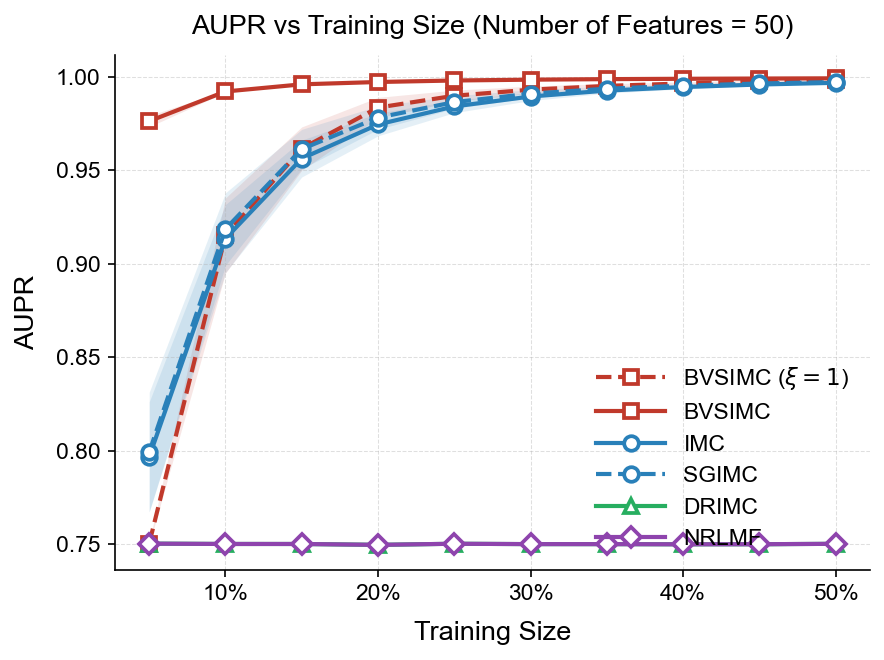

In [16]:
# individual plots
# plot_vs_train_size(final, metric="aupr", n_features=50)
plot_vs_train_size(
    final,
    metric="aupr",
    n_features=50,
    method_filters={"bissgl_xi1": {"xi": 1}},
)

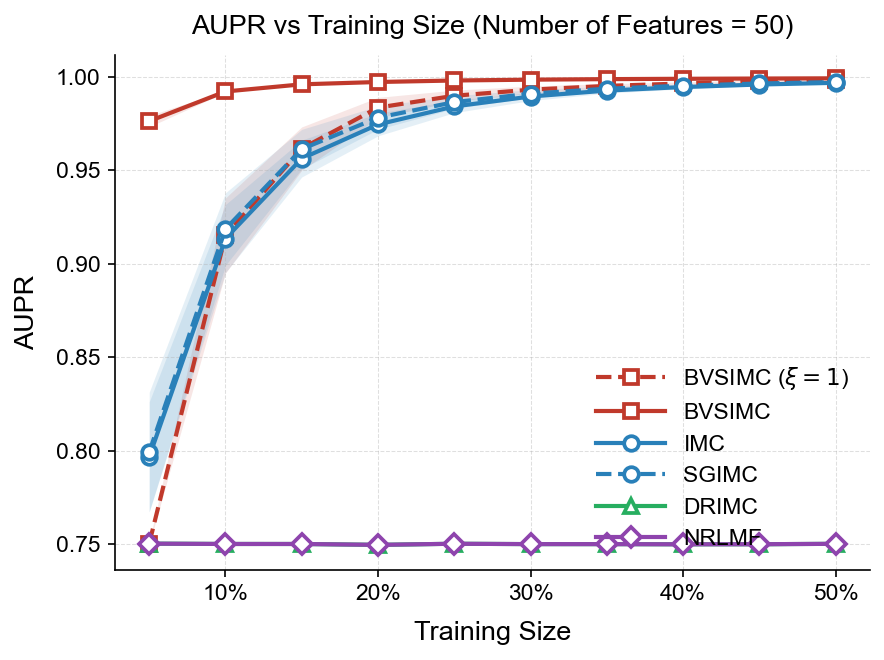

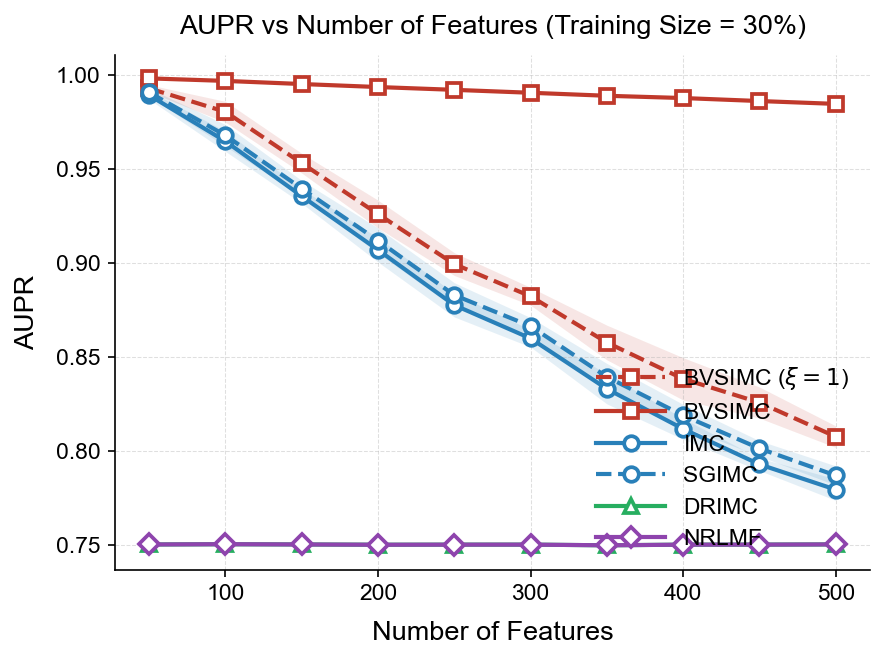

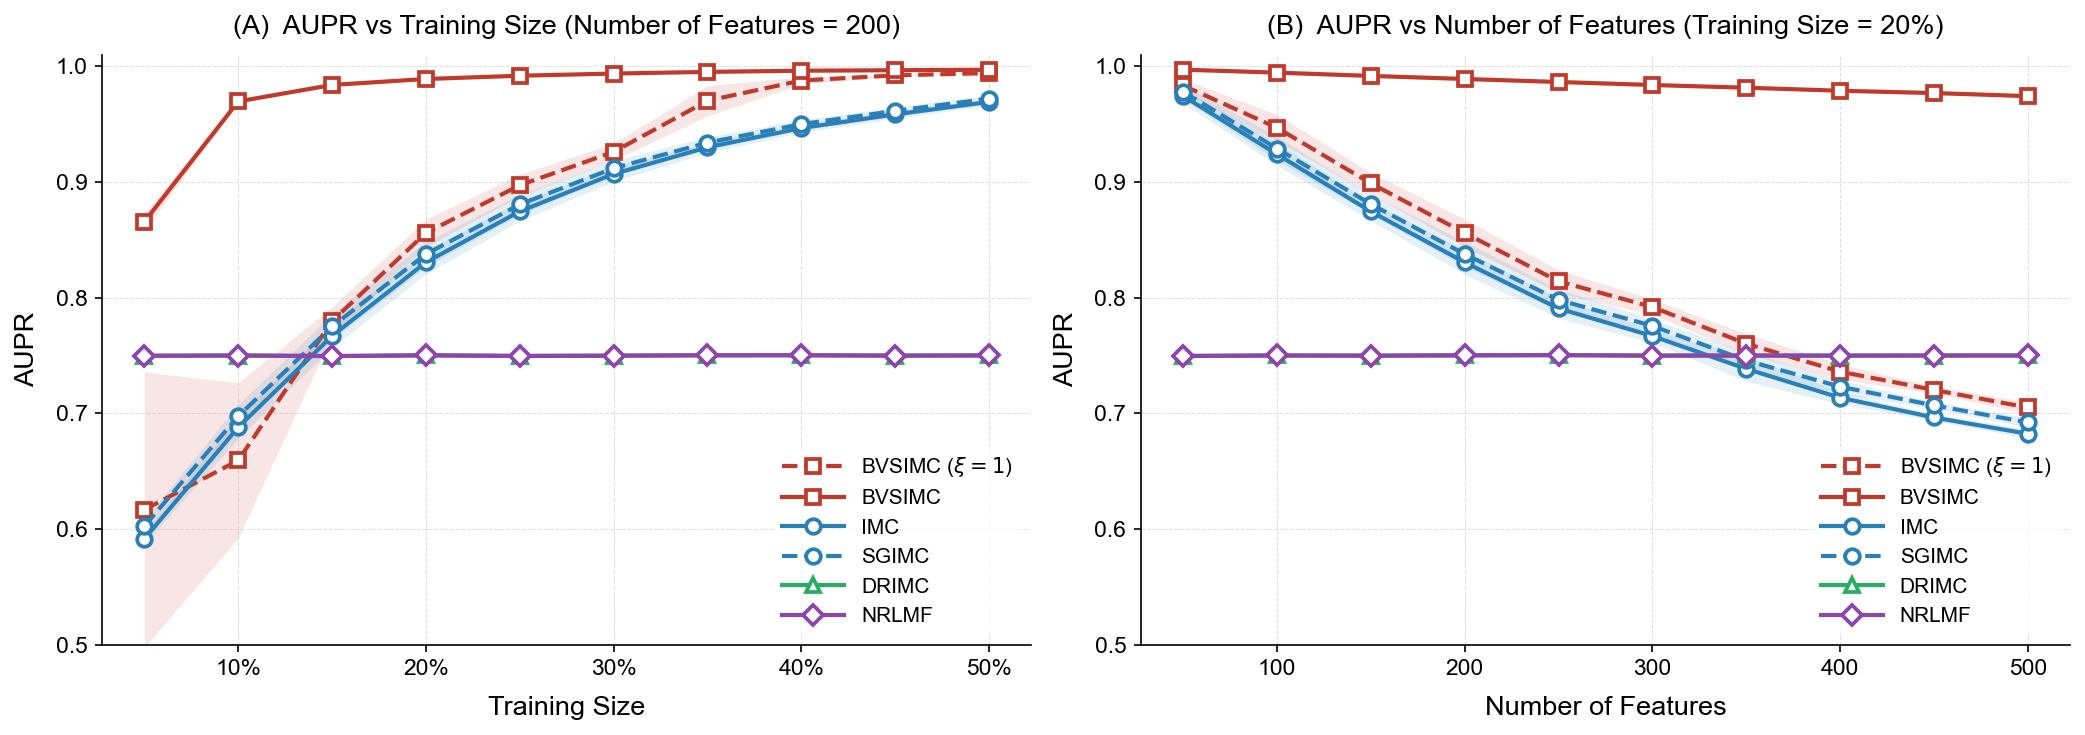

In [23]:
plot_vs_train_size(
    final,
    metric="aupr",
    n_features=50,
    method_filters={"bissgl_xi1": {"xi": 1}},
)

plot_vs_n_features(
    final,
    metric="aupr",
    train_size=0.3,
    method_filters={"bissgl_xi1": {"xi": 1}},
)

plot_both(
    final,
    metric="aupr",
    method_filters={"bissgl_xi1": {"xi": 1}},
    n_features_for_train_plot=200,
    train_size_for_feature_plot=0.2,
)